/tmp/ipython-input-3458600409.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train = train.resample('h').mean().fillna(method='ffill')
/tmp/ipython-input-3458600409.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test = test.resample('h').mean().fillna(method='ffill')


ARIMA model fitted successfully.
RMSE: 0.02203138348309065


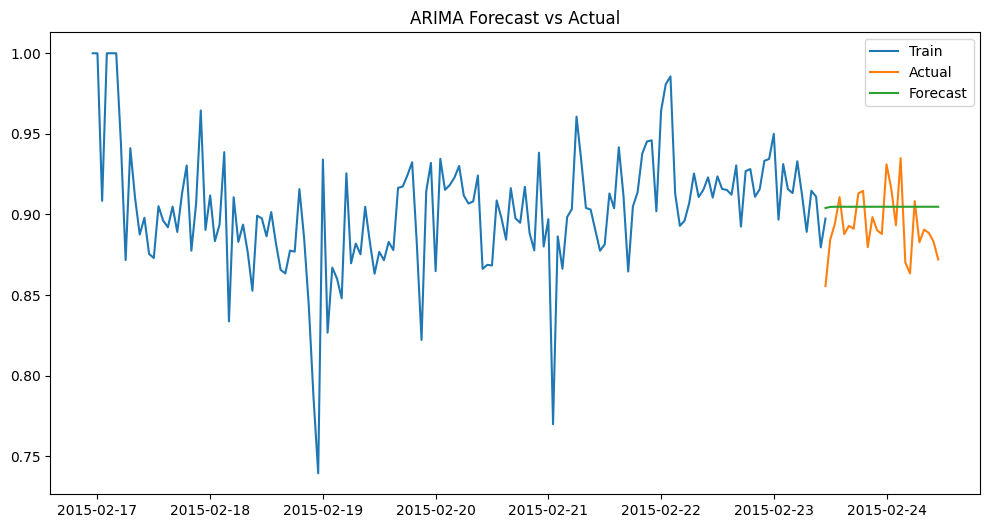

In [18]:
# -------------------------------------
# STEP 1: Ensure datetime index
# -------------------------------------
train.index = pd.to_datetime(train.index)
test.index = pd.to_datetime(test.index)

# -------------------------------------
# STEP 2: Set frequency properly and handle duplicate indices
# Resample to hourly frequency, aggregate duplicate timestamps, then forward-fill any missing hours
# -------------------------------------
train = train.resample('h').mean().fillna(method='ffill')
test = test.resample('h').mean().fillna(method='ffill')

# -------------------------------------
# STEP 3: Build ARIMA
# -------------------------------------
p, d, q = 1, 1, 1

model = ARIMA(train, order=(p, d, q))
model_fit = model.fit()

print("ARIMA model fitted successfully.")

# -------------------------------------
# STEP 4: Forecast
# -------------------------------------
forecast = model_fit.forecast(steps=len(test))

# -------------------------------------
# STEP 5: Evaluate
# -------------------------------------
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)

print("RMSE:", rmse)

# -------------------------------------
# STEP 6: Plot
# -------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast')
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()